In [3]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

import sys
sys.path.insert(0, "..")

from model.data.load_data import LoadBaseSatelliteData

In [4]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [6]:
from vis_plotting.fp_plotting import *
from vis_plotting.general_plotting import *
from vis_plotting.topog_plotting import *

SyntaxError: f-string: expecting '}' (metrics_and_figures.py, line 88)

In [9]:
data = LoadBaseSatelliteData(201601, region="BRAZIL", load_everything=True, verbose=True)
ds = data.met_file

---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_201601*.nc
no sampling was done because you didnt pass a valid sampling mode, or freq=1
Loading 1438 footprints

 ---- LOADING MET
Loading meteorology from /group/chem/acrg/met_archive/UM/SOUTHAMERICA/SOUTHAMERICA_Met_201601*.nc

---- LOADING TOPOG
trying to load topography from /group/chem/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
---- All done!


In [17]:
heights = ds.level_height.values
print(heights)

[2.0000000e+01 1.0000000e+02 3.2000000e+02 6.6000000e+02 1.1200000e+03
 1.7000000e+03 2.4000000e+03 3.2200000e+03 4.1600000e+03 5.2200000e+03
 6.4000000e+03 7.7000400e+03 9.1209043e+03 1.0667248e+04 1.2354504e+04
 1.4221144e+04 1.6347608e+04 1.8883840e+04 2.2086943e+04 2.6371023e+04]


In [7]:
#ds.load()
wind_ds = ds[['x_wind', 'y_wind','upward_air_velocity']].load()

In [ ]:
data = LoadBaseSatelliteData(2016, region="BRAZIL",freq=100, load_everything=True, verbose=True)
ds = data.met_file
full_wind_ds = ds[['x_wind', 'y_wind']].load()
full_wind_ds.to_netcdf('wind_data_2016.nc')

---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2016*.nc
reduced the number of datapoints by frequency 20
Loading 1084 footprints

 ---- LOADING MET
Loading meteorology from /group/chem/acrg/met_archive/UM/SOUTHAMERICA/SOUTHAMERICA_Met_2016*.nc

---- LOADING TOPOG
trying to load topography from /group/chem/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
---- All done!


In [10]:
ds = data.met_file

In [11]:
ds

<xarray.Dataset>
Dimensions:                              (lat: 357, levels: 20, lon: 239,
                                          time: 744)
Coordinates:
  * lat                                  (lat) float64 -60.98 -60.75 ... 22.32
    sigma                                (levels) float32 dask.array<chunksize=(20,), meta=np.ndarray>
  * levels                               (levels) int32 1 3 6 9 ... 48 51 54 57
    level_height                         (levels) float32 dask.array<chunksize=(20,), meta=np.ndarray>
  * lon                                  (lon) float64 -91.33 -90.98 ... -7.553
  * time                                 (time) datetime64[ns] 2016-01-01 ......
Data variables:
    air_pressure                         (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 10, 500), meta=np.ndarray>
    air_pressure_at_sea_level            (lat, lon, time) float32 dask.array<chunksize=(357, 120, 500), meta=np.ndarray>
    air_temperature                      (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 10, 500), meta=np.ndarray>
    atmosphere_boundary_layer_thickness  (lat, lon, time) float32 dask.array<chunksize=(357, 120, 500), meta=np.ndarray>
    surface_air_pressure                 (lat, lon, time) float32 dask.array<chunksize=(357, 120, 500), meta=np.ndarray>
    surface_upward_sensible_heat_flux    (lat, lon, time) float32 dask.array<chunksize=(357, 120, 500), meta=np.ndarray>
    upward_air_velocity                  (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 10, 500), meta=np.ndarray>
    x_wind                               (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 10, 500), meta=np.ndarray>
    y_wind                               (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 10, 500), meta=np.ndarray>
Attributes:
    source:           Data from Met Office Unified Model
    author:           Elena Fillola (ef17148)
    created:          2022-11-14 13:11
    transformations:  interpolated linearly in space to NAME resolution, inte...

In [35]:
wind_ds = ds[['x_wind', 'y_wind']].load()

In [36]:
wind_ds.to_netcdf('wind_data_201601.nc')

In [17]:
# 1. Select the level you want (e.g., level 0) and drop the time dimension by averaging
# This creates a "recipe" for the mean
mean_ds = ds.isel(levels=0).mean(dim='time')
# 2. TRIGGER THE LOAD
# This is the "heavy lifting" step. Once this finishes, everything is in RAM.
mean_ds.load()

<xarray.Dataset>
Dimensions:                              (lat: 357, lon: 239)
Coordinates:
  * lat                                  (lat) float64 -60.98 -60.75 ... 22.32
    sigma                                float32 0.9977
    levels                               int32 1
    level_height                         float32 20.0
  * lon                                  (lon) float64 -91.33 -90.98 ... -7.553
Data variables:
    air_pressure                         (lat, lon) float32 9.939e+04 ... 9.7...
    air_pressure_at_sea_level            (lat, lon) float32 9.963e+04 ... 1.0...
    air_temperature                      (lat, lon) float32 276.4 ... 293.7
    atmosphere_boundary_layer_thickness  (lat, lon) float32 447.5 ... 521.0
    surface_air_pressure                 (lat, lon) float32 9.963e+04 ... 9.8...
    surface_upward_sensible_heat_flux    (lat, lon) float32 2.316 ... 26.97
    upward_air_velocity                  (lat, lon) float32 3.279e-06 ... 0.0...
    x_wind                               (lat, lon) float32 5.974 ... -5.314
    y_wind                               (lat, lon) float32 -0.5055 ... -1.303

In [20]:
mean_wind_ds = mean_ds[['x_wind', 'y_wind']]

In [22]:
mean_wind_ds.to_netcdf('mean_wind_data.nc')

# Load data to speed up process

In [3]:
ds = xr.open_dataset("wind_data_2016.nc")
print(ds)

<xarray.Dataset>
Dimensions:       (levels: 20, lat: 357, lon: 239, time: 8760)
Coordinates:
  * lat           (lat) float64 -60.98 -60.75 -60.51 ... 21.85 22.09 22.32
  * levels        (levels) int32 1 3 6 9 12 15 18 21 ... 36 39 42 45 48 51 54 57
  * lon           (lon) float64 -91.33 -90.98 -90.62 ... -8.257 -7.905 -7.553
  * time          (time) datetime64[ns] 2016-01-01 ... 2016-12-31T23:00:00
Data variables:
    x_wind        (levels, lat, lon, time) float32 ...
    y_wind        (levels, lat, lon, time) float32 ...
    sigma         (levels) float32 ...
    level_height  (levels) float32 ...
Attributes:
    source:           Data from Met Office Unified Model
    author:           Elena Fillola (ef17148)
    created:          2022-11-14 13:11
    transformations:  interpolated linearly in space to NAME resolution, inte...


In [8]:
ds

<xarray.Dataset>
Dimensions:       (levels: 20, lat: 357, lon: 239, time: 8760)
Coordinates:
  * lat           (lat) float64 -60.98 -60.75 -60.51 ... 21.85 22.09 22.32
  * levels        (levels) int32 1 3 6 9 12 15 18 21 ... 36 39 42 45 48 51 54 57
  * lon           (lon) float64 -91.33 -90.98 -90.62 ... -8.257 -7.905 -7.553
  * time          (time) datetime64[ns] 2016-01-01 ... 2016-12-31T23:00:00
Data variables:
    x_wind        (levels, lat, lon, time) float32 ...
    y_wind        (levels, lat, lon, time) float32 ...
    sigma         (levels) float32 ...
    level_height  (levels) float32 ...
Attributes:
    source:           Data from Met Office Unified Model
    author:           Elena Fillola (ef17148)
    created:          2022-11-14 13:11
    transformations:  interpolated linearly in space to NAME resolution, inte...

In [4]:
# Every 10th time point and every 5th lat/lon
subset = ds.isel(
    time=slice(0, None, 100),
    lat=slice(0, None, 5),
    lon=slice(0, None, 5),
    levels=slice(0, 10) 
)

# Optional: To actually bring this smaller chunk into RAM
#subset.load()

In [5]:
subset.load()

<xarray.Dataset>
Dimensions:       (levels: 10, lat: 72, lon: 48, time: 88)
Coordinates:
  * lat           (lat) float64 -60.98 -59.81 -58.64 ... 19.75 20.92 22.09
  * levels        (levels) int32 1 3 6 9 12 15 18 21 24 27
  * lon           (lon) float64 -91.33 -89.57 -87.81 ... -12.13 -10.37 -8.609
  * time          (time) datetime64[ns] 2016-01-01 ... 2016-12-29T12:00:00
Data variables:
    x_wind        (levels, lat, lon, time) float32 13.07 9.741 ... 10.07 17.35
    y_wind        (levels, lat, lon, time) float32 10.05 11.54 ... 4.207 -8.467
    sigma         (levels) float32 0.9977 0.9886 0.9639 ... 0.6669 0.5823 0.4938
    level_height  (levels) float32 20.0 100.0 320.0 ... 4.16e+03 5.22e+03
Attributes:
    source:           Data from Met Office Unified Model
    author:           Elena Fillola (ef17148)
    created:          2022-11-14 13:11
    transformations:  interpolated linearly in space to NAME resolution, inte...

In [23]:
subset

<xarray.Dataset>
Dimensions:       (levels: 10, lat: 72, lon: 48, time: 88)
Coordinates:
  * lat           (lat) float64 -60.98 -59.81 -58.64 ... 19.75 20.92 22.09
  * levels        (levels) int32 1 3 6 9 12 15 18 21 24 27
  * lon           (lon) float64 -91.33 -89.57 -87.81 ... -12.13 -10.37 -8.609
  * time          (time) datetime64[ns] 2016-01-01 ... 2016-12-29T12:00:00
Data variables:
    x_wind        (levels, lat, lon, time) float32 13.07 9.741 ... 10.07 17.35
    y_wind        (levels, lat, lon, time) float32 10.05 11.54 ... 4.207 -8.467
    sigma         (levels) float32 0.9977 0.9886 0.9639 ... 0.6669 0.5823 0.4938
    level_height  (levels) float32 20.0 100.0 320.0 ... 4.16e+03 5.22e+03
Attributes:
    source:           Data from Met Office Unified Model
    author:           Elena Fillola (ef17148)
    created:          2022-11-14 13:11
    transformations:  interpolated linearly in space to NAME resolution, inte...

## Characterization of Planetary Boundary Layer height

In [22]:
subset = data.met_file.isel(
    time=slice(0, None, 200),
    lat=slice(0, None, 5),
    lon=slice(0, None, 5),
    levels=slice(0, 2) 
)
subset

<xarray.Dataset>
Dimensions:                              (lat: 72, levels: 2, lon: 48, time: 44)
Coordinates:
  * lat                                  (lat) float64 -60.98 -59.81 ... 22.09
    sigma                                (levels) float32 dask.array<chunksize=(2,), meta=np.ndarray>
  * levels                               (levels) int32 1 3
    level_height                         (levels) float32 dask.array<chunksize=(2,), meta=np.ndarray>
  * lon                                  (lon) float64 -91.33 -89.57 ... -8.609
  * time                                 (time) datetime64[ns] 2016-01-01 ......
Data variables:
    air_pressure                         (levels, lat, lon, time) float32 dask.array<chunksize=(2, 72, 2, 4), meta=np.ndarray>
    air_pressure_at_sea_level            (lat, lon, time) float32 dask.array<chunksize=(72, 24, 4), meta=np.ndarray>
    air_temperature                      (levels, lat, lon, time) float32 dask.array<chunksize=(2, 72, 2, 4), meta=np.ndarray>
    atmosphere_boundary_layer_thickness  (lat, lon, time) float32 dask.array<chunksize=(72, 24, 4), meta=np.ndarray>
    surface_air_pressure                 (lat, lon, time) float32 dask.array<chunksize=(72, 24, 4), meta=np.ndarray>
    surface_upward_sensible_heat_flux    (lat, lon, time) float32 dask.array<chunksize=(72, 24, 4), meta=np.ndarray>
    upward_air_velocity                  (levels, lat, lon, time) float32 dask.array<chunksize=(2, 72, 2, 4), meta=np.ndarray>
    x_wind                               (levels, lat, lon, time) float32 dask.array<chunksize=(2, 72, 2, 4), meta=np.ndarray>
    y_wind                               (levels, lat, lon, time) float32 dask.array<chunksize=(2, 72, 2, 4), meta=np.ndarray>
Attributes:
    source:           Data from Met Office Unified Model
    author:           Elena Fillola (ef17148)
    created:          2022-11-14 13:11
    transformations:  interpolated linearly in space to NAME resolution, inte...

In [23]:
subset.load()

<xarray.Dataset>
Dimensions:                              (lat: 72, levels: 2, lon: 48, time: 44)
Coordinates:
  * lat                                  (lat) float64 -60.98 -59.81 ... 22.09
    sigma                                (levels) float32 0.9977 0.9886
  * levels                               (levels) int32 1 3
    level_height                         (levels) float32 20.0 100.0
  * lon                                  (lon) float64 -91.33 -89.57 ... -8.609
  * time                                 (time) datetime64[ns] 2016-01-01 ......
Data variables:
    air_pressure                         (levels, lat, lon, time) float32 9.6...
    air_pressure_at_sea_level            (lat, lon, time) float32 9.695e+04 ....
    air_temperature                      (levels, lat, lon, time) float32 273...
    atmosphere_boundary_layer_thickness  (lat, lon, time) float32 451.8 ... 5...
    surface_air_pressure                 (lat, lon, time) float32 9.695e+04 ....
    surface_upward_sensible_heat_flux    (lat, lon, time) float32 40.3 ... 7.145
    upward_air_velocity                  (levels, lat, lon, time) float32 -5e...
    x_wind                               (levels, lat, lon, time) float32 13....
    y_wind                               (levels, lat, lon, time) float32 10....
Attributes:
    source:           Data from Met Office Unified Model
    author:           Elena Fillola (ef17148)
    created:          2022-11-14 13:11
    transformations:  interpolated linearly in space to NAME resolution, inte...

### Plotting atmosphetric boundary layer height

Based on this paper - A high-resolution planetary boundary layer height seasonal climatology from GNSS radio occultations  https://www.sciencedirect.com/science/article/pii/S0034425722001511

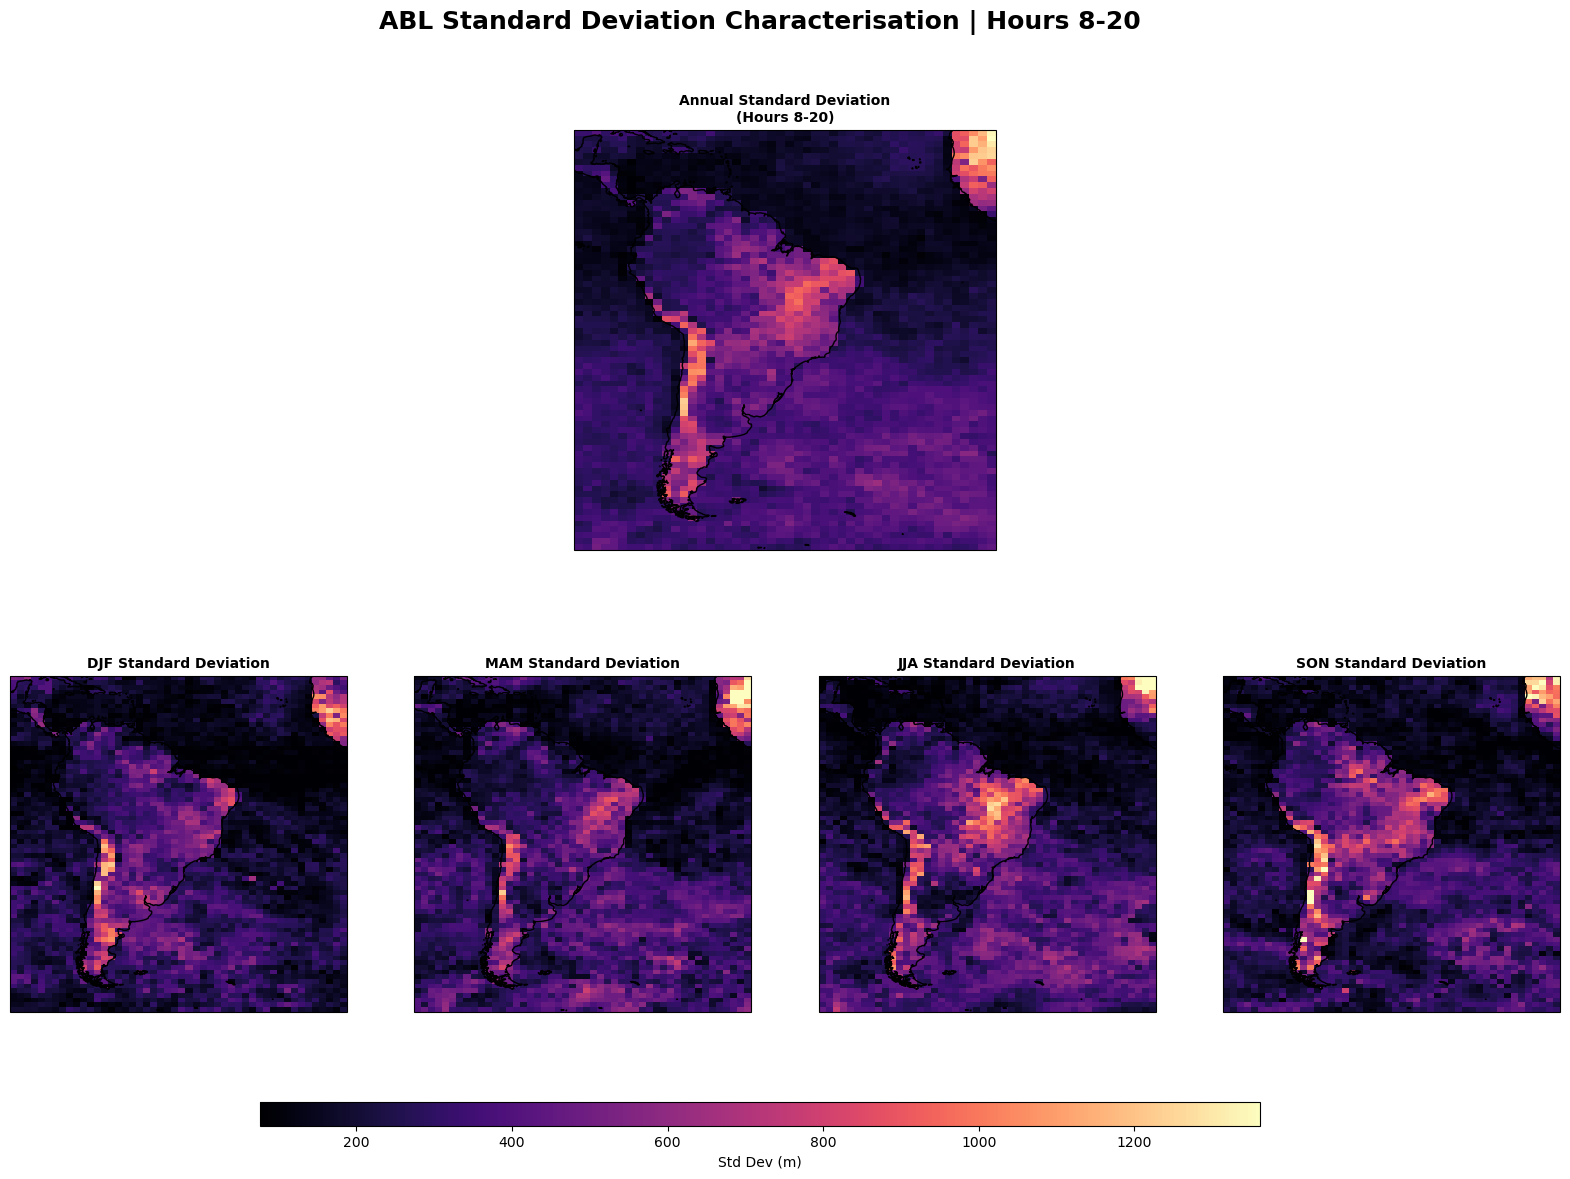

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def plot_single_abl_map(data, ax=None, vmin=None, vmax=None, cmap='viridis', title=None, label='Value'):
    """
    Plots a single spatial map of ABL data (Mean, Std Dev, or Count).
    """
    if ax is None:
        fig = plt.figure(figsize=(10, 8))
        ax = plt.axes(projection=ccrs.PlateCarree())
    # Bawid - put coastline
    ax.coastlines(resolution='50m', color='black', linewidth=1)
    
    # Use pcolormesh for grid-based visualization
    im = ax.pcolormesh(data.lon, data.lat, data, 
                       vmin=vmin, vmax=vmax, 
                       cmap=cmap, transform=ccrs.PlateCarree())
    
    if title:
        ax.set_title(title, fontweight='bold', fontsize=10)
    
    return im

def plot_abl_characterisation(ds, mode='mean', v_range=None, cmap=None, hour_range=None):
    """
    Generates Annual and Seasonal ABL maps for 'mean', 'std', or 'count'.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset containing 'atmosphere_boundary_layer_thickness'.
    mode : str, optional
        'mean' (average), 'std' (variability), or 'count' (number of observations).
    v_range : tuple, optional
        (min, max) for colorbar. 
    cmap : str, optional
        Colormap name. Defaults: 'viridis' (mean), 'magma' (std), 'Blues' (count).
    hour_range : list or tuple, optional
        [start, end] hour filter.
    """
    # 1. Apply Hour Filter
    if hour_range is not None:
        subset = ds.where(
            (ds['time.hour'] >= hour_range[0]) & (ds['time.hour'] <= hour_range[1]), 
            drop=True
        )
        time_label = f"Hours {hour_range[0]}-{hour_range[1]}"
    else:
        subset = ds
        time_label = "All Day"

    # 2. Select Statistic Mode
    data_var = subset['atmosphere_boundary_layer_thickness']
    
    if mode == 'count':
        # Nawid - plot the count of the different locations
        # Count non-NaN values along the time dimension
        annual_stat = data_var.notnull().sum(dim='time')
        seasonal_stat = data_var.notnull().groupby('time.season').sum(dim='time')
        title_suffix = "Observation Count"
        cmap = cmap or 'Blues'
        label = "Number of Observations"
    elif mode == 'std':
        # Nawid - plot the standard deviation for the different locations
        annual_stat = data_var.std(dim='time')
        seasonal_stat = data_var.groupby('time.season').std(dim='time')
        title_suffix = "Standard Deviation"
        cmap = cmap or 'magma'
        label = "Std Dev (m)"
    else:
        # Nawid - get the mean of the different locations
        annual_stat = data_var.mean(dim='time')
        seasonal_stat = data_var.groupby('time.season').mean(dim='time')
        title_suffix = "Mean Height"
        cmap = cmap or 'viridis'
        label = "Mean Height (m)"

    # 3. Setup Layout
    fig = plt.figure(figsize=(20, 12))
    gs = plt.GridSpec(2, 4, figure=fig, height_ratios=[1, 1])
    
    # Handle v_range
    # Nawid - get the min and max values for plotting purposes
    vmin = v_range[0] if v_range else annual_stat.min().values
    vmax = v_range[1] if v_range else annual_stat.max().values

    # 4. Plot Annual (Top Row)
    ax_ann = fig.add_subplot(gs[0, 1:3], projection=ccrs.PlateCarree())
    # Nawid - plot the annual plot
    plot_single_abl_map(annual_stat, ax=ax_ann, vmin=vmin, vmax=vmax, 
                        cmap=cmap, title=f"Annual {title_suffix}\n({time_label})")
    
    # 5. Plot Seasons (Bottom Row)
    seasons = ['DJF', 'MAM', 'JJA', 'SON']
    im = None
    for i, season in enumerate(seasons):
        if season in seasonal_stat.season:
            ax_sea = fig.add_subplot(gs[1, i], projection=ccrs.PlateCarree())
            # Nawid - plot for each season
            im = plot_single_abl_map(seasonal_stat.sel(season=season), 
                                     ax=ax_sea, vmin=vmin, vmax=vmax, 
                                     cmap=cmap, title=f"{season} {title_suffix}")
    
    # 6. Unified Colorbar
    if im:
        cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.02])
        fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label=label)
    
    plt.suptitle(f"ABL {title_suffix} Characterisation | {time_label}", 
                  fontsize=18, fontweight='bold', y=0.98)
    plt.show()

# --- Example Usage ---
plot_abl_characterisation(subset, mode='std', hour_range=[8, 20])

### characterize PBLH through Dynamical (vertical shear)

In [19]:
subset

<xarray.Dataset>
Dimensions:       (levels: 10, lat: 72, lon: 48, time: 88)
Coordinates:
  * lat           (lat) float64 -60.98 -59.81 -58.64 ... 19.75 20.92 22.09
  * levels        (levels) int32 1 3 6 9 12 15 18 21 24 27
  * lon           (lon) float64 -91.33 -89.57 -87.81 ... -12.13 -10.37 -8.609
  * time          (time) datetime64[ns] 2016-01-01 ... 2016-12-29T12:00:00
Data variables:
    x_wind        (levels, lat, lon, time) float32 13.07 9.741 ... 10.07 17.35
    y_wind        (levels, lat, lon, time) float32 10.05 11.54 ... 4.207 -8.467
    sigma         (levels) float32 0.9977 0.9886 0.9639 ... 0.6669 0.5823 0.4938
    level_height  (levels) float32 20.0 100.0 320.0 ... 4.16e+03 5.22e+03
Attributes:
    source:           Data from Met Office Unified Model
    author:           Elena Fillola (ef17148)
    created:          2022-11-14 13:11
    transformations:  interpolated linearly in space to NAME resolution, inte...

Interpolating and calculating PBLH (this may take a moment)...


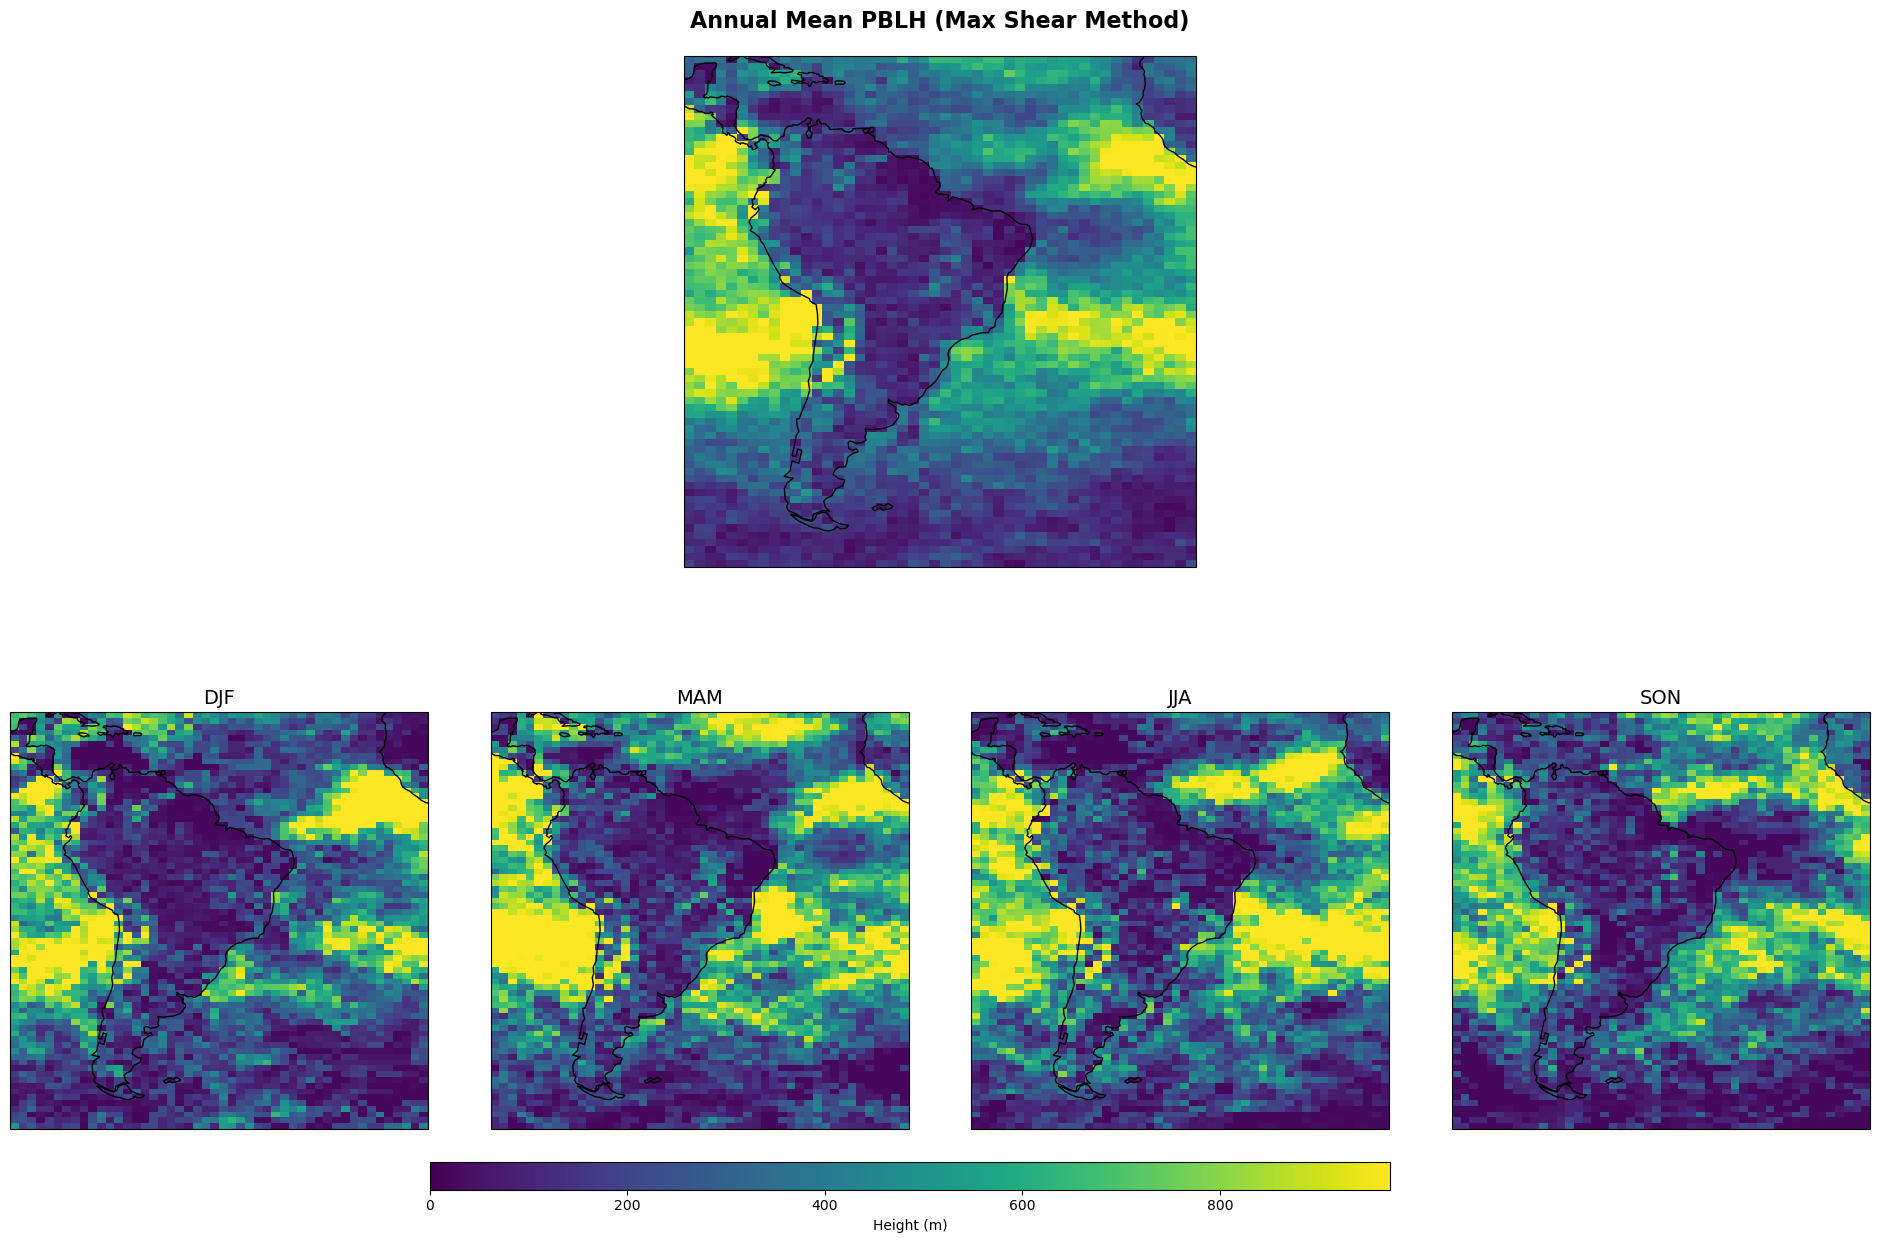

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import xarray as xr
import numpy as np
import cartopy.crs as ccrs

def interpolate_vertical_profile(ds, target_heights=None,res=50):
    """
    Interpolates wind data to a finer vertical resolution using level_height.
    """
    # Use level_height as the coordinate to interpolate against
    # We rename it temporarily to 'levels' so xarray knows which dimension to replace
    ds_coords = ds.set_index(levels="level_height")
    
    if target_heights is None:
        max_h = float(ds.level_height.max())
        min_h = float(ds.level_height.min())
        # Create a fine grid every 'res' meters
        target_heights = np.arange(min_h, max_h, res)

    # Now interpolate along the new coordinate
    ds_interp = ds_coords.interp(levels=target_heights, method='linear')
    return ds_interp

def characterize_pblh(ds_interp):
    """
    Characterizes the PBLH by finding height of max vertical shear.
    """
    # Now that 'levels' is actually height in meters, differentiate works correctly
    du_dz = ds_interp.x_wind.differentiate("levels")
    dv_dz = ds_interp.y_wind.differentiate("levels")
    # Nawid - calculate shear
    shear_mag = np.sqrt(du_dz**2 + dv_dz**2)
    
    # Identify PBLH
    # Nawid - height which the shear is maximum is the PBLH
    pblh = shear_mag.idxmax(dim="levels")
    return pblh

def plot_pblh_analysis(dataset, res=50):
    """
    Combines interpolation, characterization, and 5-panel seasonal plotting.
    """
    # 1. Process Data
    print("Interpolating and calculating PBLH (this may take a moment)...")
    # Nawid - interpolate the wind data for the different heights
    ds_fine = interpolate_vertical_profile(dataset,res=res)
    # Nawid - calculate the PBLH for the different times and different positions
    pblh_all = characterize_pblh(ds_fine)
    
    # 2. Setup Annual and Max Scaling
    # Nawid - calculate the average PBLH for the different positions
    pblh_annual = pblh_all.mean("time")
    # Set a robust max value for the colorbar (95th percentile to avoid outliers)
    max_val = float(pblh_annual.quantile(0.95)) 

    # 3. Figure Setup
    fig = plt.figure(figsize=(24, 14))
    gs = gridspec.GridSpec(2, 4, height_ratios=[1.2, 1])

    # --- Plot Annual (Top Center) ---
    ax_ann = fig.add_subplot(gs[0, 1:3], projection=ccrs.PlateCarree())
    im = pblh_annual.plot(
        ax=ax_ann, x='lon', y='lat', transform=ccrs.PlateCarree(),
        cmap='viridis', vmin=0, vmax=max_val, add_colorbar=False
    )
    ax_ann.coastlines()
    #ax_ann.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    ax_ann.set_title("Annual Mean PBLH (Max Shear Method)", fontsize=16, fontweight='bold', pad=20)

    # --- Seasonal Loop (Bottom Row) ---
    seasons = [('DJF', 'DJF'), ('MAM', 'MAM'), 
               ('JJA', 'JJA'), ('SON', 'SON')]
    
    for i, (code, name) in enumerate(seasons):
        ax_s = fig.add_subplot(gs[1, i], projection=ccrs.PlateCarree())
        pblh_s = pblh_all.sel(time=pblh_all.time.dt.season == code).mean("time")
        
        pblh_s.plot(
            ax=ax_s, x='lon', y='lat', transform=ccrs.PlateCarree(),
            cmap='viridis', vmin=0, vmax=max_val, add_colorbar=False
        )
        ax_s.coastlines()
        ax_s.set_title(name, fontsize=14)

    # 4. Shared Colorbar
    cbar_ax = fig.add_axes([0.3, 0.07, 0.4, 0.02])
    fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Height (m)')
    
    plt.subplots_adjust(hspace=0.3, wspace=0.15)
    plt.show()

# Run the pipeline
plot_pblh_analysis(subset,res=10)

# Velocity wind

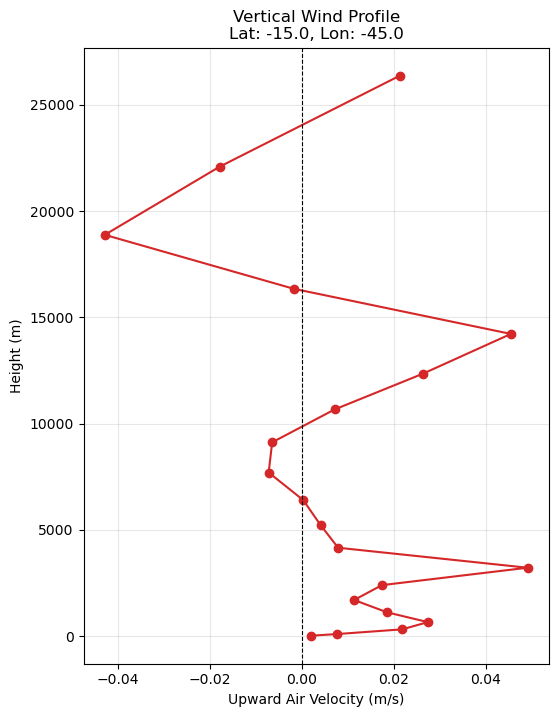

In [10]:
def plot_vertical_velocity_profile(ds, lat_val, lon_val, time_idx=0):
    # Nawid - function currently for a single location, and a particular time, do we want seasonally, or average over different locations
    # Select point and time
    wind_info = ds.sel(lat=lat_val, lon=lon_val, method='nearest').isel(time=time_idx)
    
    plt.figure(figsize=(6, 8))
    # Nawid - wind as upward win as function of height
    plt.plot(wind_info['upward_air_velocity'], wind_info['level_height'], marker='o', color='tab:red')
    
    plt.axvline(0, color='black', linestyle='--', linewidth=0.8) # Zero line
    plt.xlabel('Upward Air Velocity (m/s)')
    plt.ylabel('Height (m)')
    plt.title(f'Vertical Wind Profile\nLat: {lat_val}, Lon: {lon_val}')
    plt.grid(True, alpha=0.3)
    plt.show()

plot_vertical_velocity_profile(wind_ds,lat_val=-15.0, lon_val=-45.0,time_idx=0)

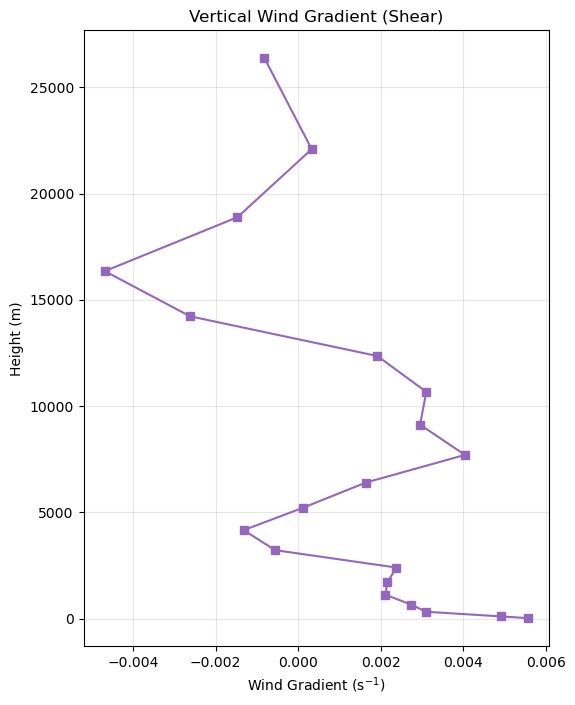

In [ ]:
def plot_wind_gradient(ds, lat_val, lon_val, time_idx=0):
    # Nawid - plots wiind gradient of the horizontal wind at a particualr location as a funciton of height
    # 1. Select data
    subset = ds.sel(lat=lat_val, lon=lon_val, method='nearest').isel(time=time_idx)
    
    # 2. Calculate horizontal wind speed
    speed = np.sqrt(subset['x_wind']**2 + subset['y_wind']**2)
    
    # 3. Calculate Gradient (dU/dZ)
    # np.gradient handles the spacing between level_heights automatically
    # Nawid - calculates 
    shear = np.gradient(speed, subset['level_height'])
    
    fig, ax = plt.subplots(figsize=(6, 8))
    ax.plot(shear, subset['level_height'], marker='s', color='tab:purple', label='dU/dZ')
    
    ax.set_xlabel('Wind Gradient (s$^{-1}$)')
    ax.set_ylabel('Height (m)')
    ax.set_title('Wind Gradient')
    ax.grid(True, alpha=0.3)
    plt.show()

plot_wind_gradient(wind_ds,lat_val=-15.0, lon_val=-45.0,time_idx=0)

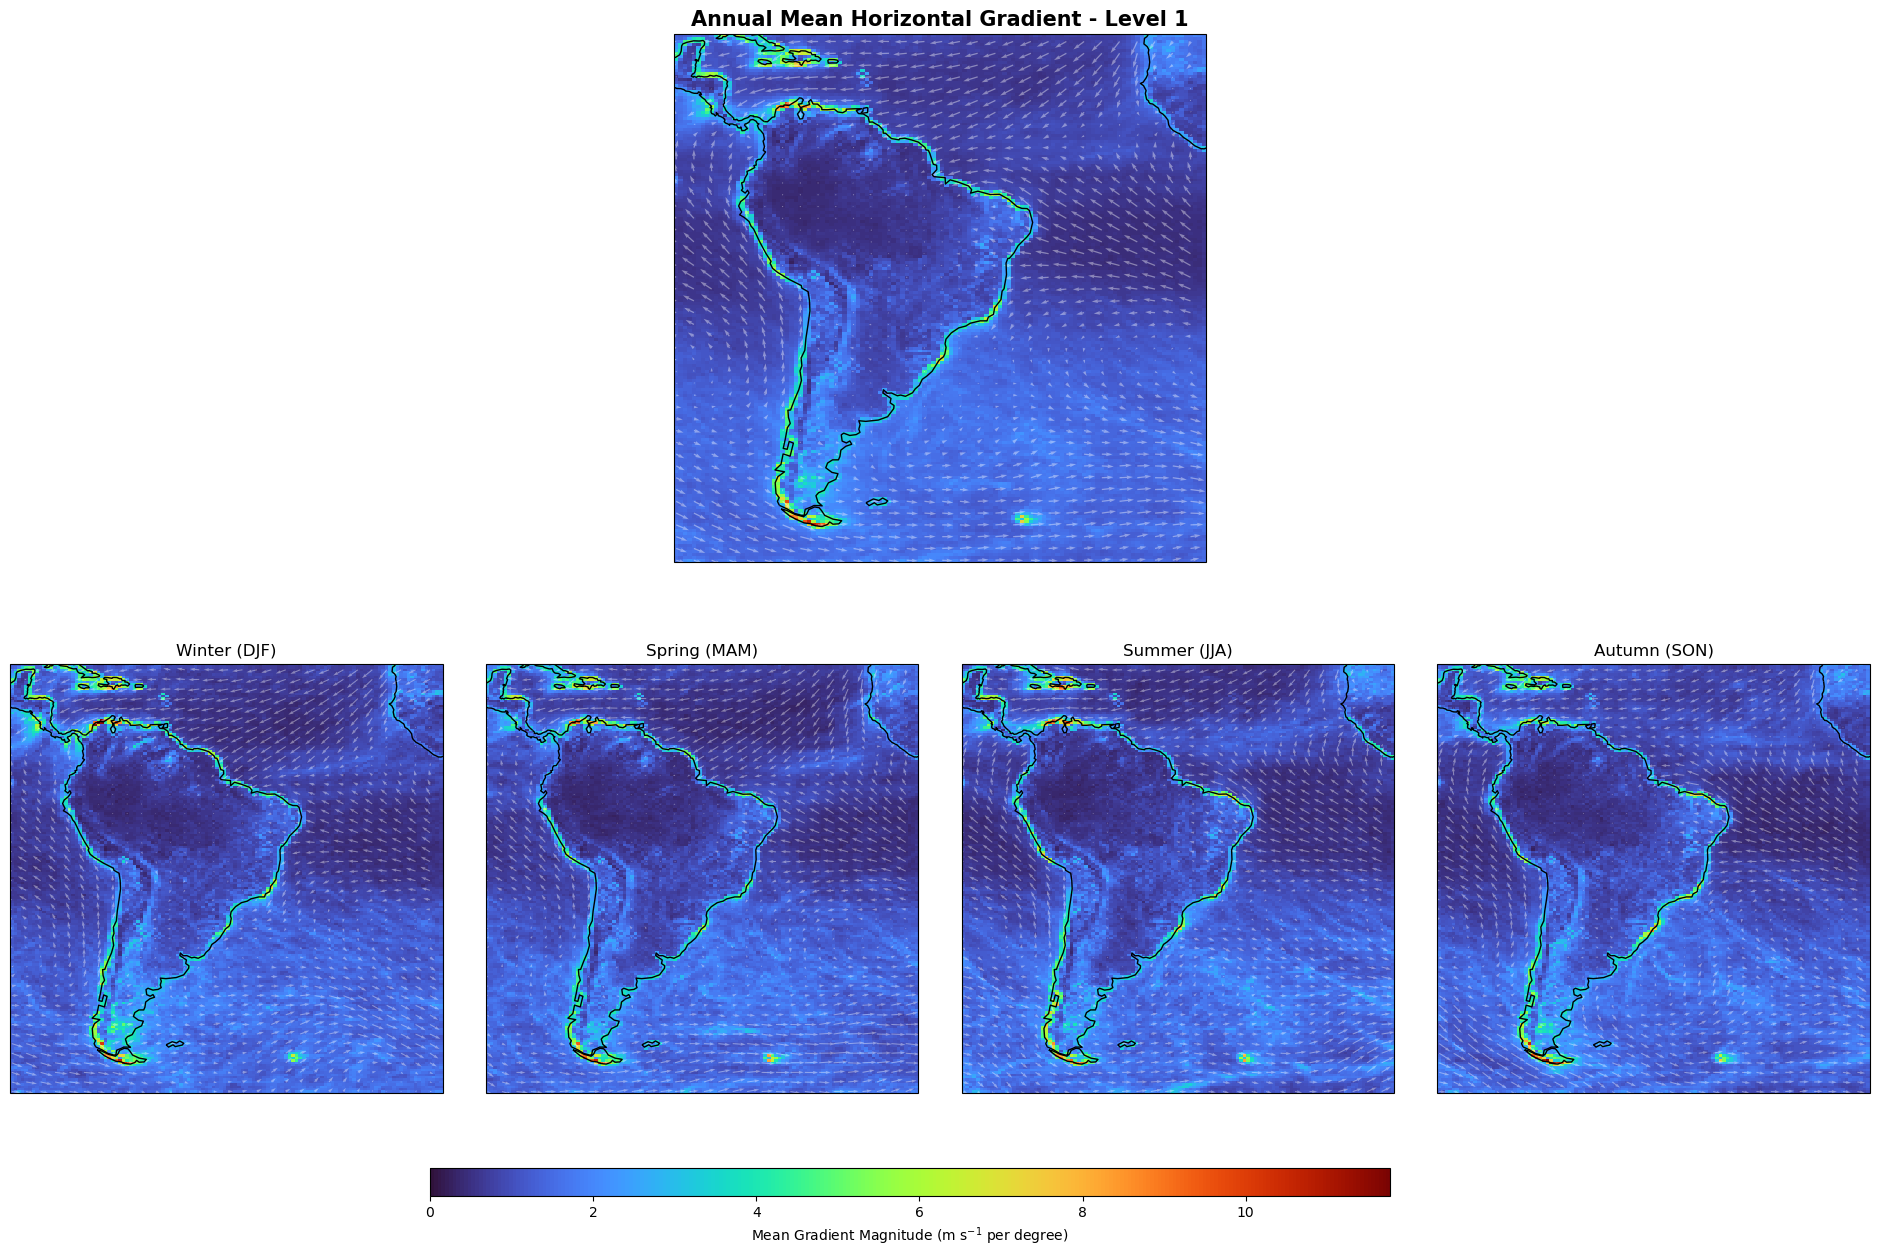

In [ ]:
import matplotlib.gridspec as gridspec
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def plot_gradient_analysis(dataset, level=1, skip=5):
    """
    Creates a 5-panel analysis showing the Mean Horizontal Wind Gradient 
    for the entire year and by meteorological season using Xarray differentiation.

    Parameters
    ----------
    dataset : xarray.Dataset
        The input dataset containing 'x_wind' and 'y_wind'.
    level : int, default 1
        The vertical level to extract.
    skip : int, default 5
        The stride for the context quiver arrows.
    """
    
    def get_grad_mag(ds_slice):
        """Calculates magnitude of the spatial gradient for a 3D/4D DataArray."""
        # Calculate speed (dims: lat, lon, time)
        speed = np.sqrt(ds_slice.x_wind**2 + ds_slice.y_wind**2)
        
        # xarray.differentiate computes the central difference 
        # relative to the coordinate values (degrees in this case)
        grad_x = speed.differentiate("lon")
        grad_y = speed.differentiate("lat")
        
        return np.sqrt(grad_x**2 + grad_y**2)

    # 1. Pre-process Data
    ds_lev = dataset.sel(levels=level)
    
    # Calculate Annual Mean Gradient (Gradient of magnitude, averaged over time)
    annual_grad = get_grad_mag(ds_lev).mean("time")
    
    # Get mean wind components for quiver overlay
    u_ann = ds_lev.x_wind.mean("time")
    v_ann = ds_lev.y_wind.mean("time")

    # Consistent color scale based on the annual maximum
    max_grad = float(annual_grad.max()) * 1.1

    # 2. Setup Figure with GridSpec
    fig = plt.figure(figsize=(24, 14))
    gs = gridspec.GridSpec(2, 4, height_ratios=[1.2, 1])

    # 3. Plot Annual Gradient (Center Top)
    ax_annual = fig.add_subplot(gs[0, 1:3], projection=ccrs.PlateCarree())
    
    # Plot gradient background
    im = annual_grad.plot(
        ax=ax_annual, x='lon', y='lat', transform=ccrs.PlateCarree(),
        cmap='turbo', add_colorbar=False, vmin=0, vmax=max_grad
    )
    
    # Overlay white quivers for context
    ax_annual.quiver(u_ann.lon[::skip], u_ann.lat[::skip], 
                     u_ann.values[::skip, ::skip], v_ann.values[::skip, ::skip], 
                     color='white', alpha=0.4, transform=ccrs.PlateCarree())
    
    ax_annual.coastlines()
    ax_annual.set_title(f'Annual Mean Horizontal Gradient - Level {level}', fontsize=15, fontweight='bold')

    # 4. Seasonal Loop
    seasons = [('DJF', 'DJF'), ('MAM', 'MAM'), 
               ('JJA', 'JJA'), ('SON', 'SON')]

    for i, (season_code, season_name) in enumerate(seasons):
        ax_s = fig.add_subplot(gs[1, i], projection=ccrs.PlateCarree())
        
        # Seasonal subset
        ds_season = ds_lev.sel(time=ds_lev.time.dt.season == season_code)
        
        # Calculate seasonal mean gradient and components
        grad_s = get_grad_mag(ds_season).mean("time")
        u_s = ds_season.x_wind.mean("time")
        v_s = ds_season.y_wind.mean("time")
        
        # Plot gradient
        grad_s.plot(
            ax=ax_s, x='lon', y='lat', transform=ccrs.PlateCarree(),
            cmap='turbo', add_colorbar=False, vmin=0, vmax=max_grad
        )
        
        # Plot quivers
        ax_s.quiver(u_s.lon[::skip], u_s.lat[::skip], 
                    u_s.values[::skip, ::skip], v_s.values[::skip, ::skip], 
                    color='white', alpha=0.4, transform=ccrs.PlateCarree())
        
        ax_s.coastlines()
        ax_s.set_title(season_name)

    # 5. Shared Colorbar
    cbar_ax = fig.add_axes([0.3, 0.05, 0.4, 0.02])
    fig.colorbar(im, cax=cbar_ax, orientation='horizontal', 
                 label='Mean Gradient Magnitude (m s$^{-1}$ per degree)')

    plt.subplots_adjust(hspace=0.2, wspace=0.1, bottom=0.12)
    plt.show()

plot_gradient_analysis(subset,skip=4)


## Quiver map using u and v

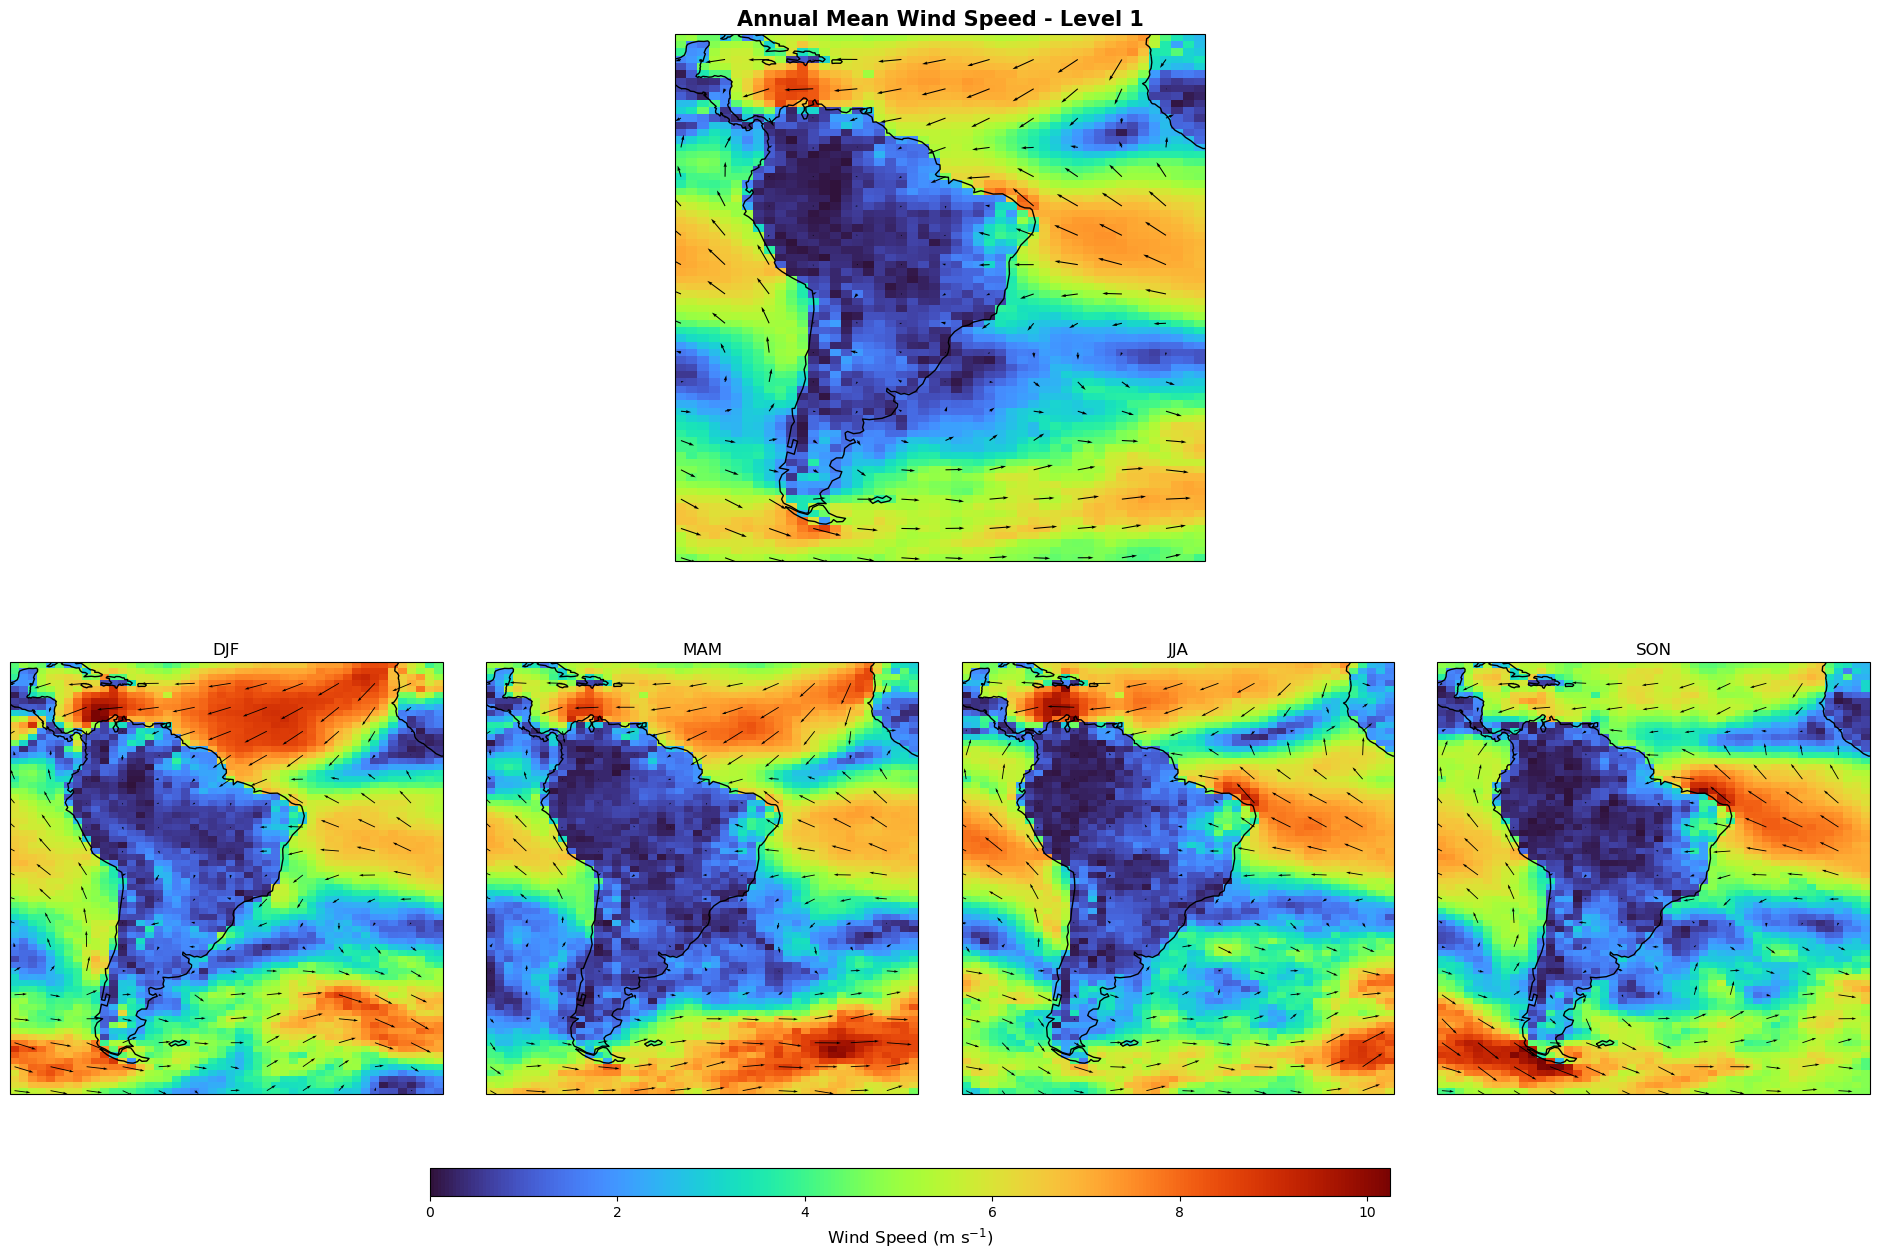

In [13]:
def quiver_map(u_mean, v_mean, ax, max_speed=None, add_colorbar=True, skip = 1):
    """
    Plots a wind speed heatmap with overlaid quiver arrows on a given axis.

    Parameters
    ----------
    u_mean : xarray.DataArray
        2D array (lat, lon) of the time-averaged eastward wind component.
    v_mean : xarray.DataArray
        2D array (lat, lon) of the time-averaged northward wind component.
    ax : matplotlib.axes.Axes
        The axis object with a Cartopy projection (e.g., ccrs.PlateCarree()).
    max_speed : float, optional
        The maximum value for the colorbar scale. Useful for consistent 
        scaling across subplots.
    add_colorbar : bool, default True
        Whether to draw a colorbar for the wind speed.

    Returns
    -------
    im : matplotlib.collections.QuadMesh
        The color mesh object, useful for creating shared colorbars.
    """
    # Calculate speed
    wind_speed = np.sqrt(u_mean**2 + v_mean**2)
    
    # Plot background
    im = wind_speed.plot(
        ax=ax, x='lon', y='lat', transform=ccrs.PlateCarree(),
        cmap='turbo', add_colorbar=add_colorbar,
        vmin=0, vmax=max_speed, # Use max_speed for shared colorbar scaling
        cbar_kwargs={'label': 'm s$^{-1}$', 'orientation': 'horizontal', 'pad': 0.08} if add_colorbar else None
    )

    # Quiver logic
    #skip = 4 # Adjusted skip for subsetted data
    q = ax.quiver(
        u_mean.lon[::skip], u_mean.lat[::skip], 
        u_mean.values[::skip, ::skip], v_mean.values[::skip, ::skip],
        transform=ccrs.PlateCarree(), color='black', scale=150, width=0.002
    )
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    # Nawid - used to make gridlines (showing lat and lon)
    #ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    return im


import matplotlib.gridspec as gridspec

def plot_wind_analysis(dataset, level=1, skip=5):
    """
    Creates a comprehensive wind analysis figure showing the Annual Mean 
    alongside a 4-panel seasonal breakdown (DJF, MAM, JJA, SON).

    Parameters
    ----------
    dataset : xarray.Dataset
        The input dataset containing 'x_wind', 'y_wind', and 'time'.
    level : int, default 1
        The vertical level to extract from the dataset.
    skip : int, default 5
        The stride for quiver arrows (higher = fewer arrows).

    Returns
    -------
    None
        Displays a 5-panel matplotlib figure.
    """
    # 1. Pre-process Data
    ds_lev = dataset.sel(levels=level)
    
    # Calculate Annual Mean
    u_annual = ds_lev.x_wind.mean("time")
    v_annual = ds_lev.y_wind.mean("time")
    
    # Calculate global max speed for a consistent colorbar across all 5 plots
    # This ensures color intensity is scientifically comparable
    speed_annual = np.sqrt(u_annual**2 + v_annual**2)
    max_speed = float(speed_annual.max()) * 1.1

    # 2. Setup Figure with GridSpec (2 rows: Top for Annual, Bottom for Seasonal)
    fig = plt.figure(figsize=(24, 14))
    gs = gridspec.GridSpec(2, 4, height_ratios=[1.2, 1])

    # 3. Plot Annual Mean (Spans middle two columns of top row)
    ax_annual = fig.add_subplot(gs[0, 1:3], projection=ccrs.PlateCarree())
    im = quiver_map(u_annual, v_annual, ax_annual, max_speed=max_speed, add_colorbar=False, skip=skip)
    ax_annual.set_title(f'Annual Mean Wind Speed - Level {level}', fontsize=15, fontweight='bold')

    # 4. Plot Seasonal Breakdowns
    seasons = [('DJF', 'DJF'), ('MAM', 'MAM'), 
               ('JJA', 'JJA'), ('SON', 'SON')]

    for i, (season_code, season_name) in enumerate(seasons):
        ax_season = fig.add_subplot(gs[1, i], projection=ccrs.PlateCarree())
        
        # Subset and Mean
        seasonal_data = ds_lev.sel(time=ds_lev.time.dt.season == season_code)
        u_s = seasonal_data.x_wind.mean("time")
        v_s = seasonal_data.y_wind.mean("time")
        
        # Plot
        quiver_map(u_s, v_s, ax_season, max_speed=max_speed, add_colorbar=False, skip=skip)
        ax_season.set_title(season_name, fontsize=12)

    # 5. Add Single Shared Colorbar
    cbar_ax = fig.add_axes([0.3, 0.05, 0.4, 0.02]) # [left, bottom, width, height]
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Wind Speed (m s$^{-1}$)', fontsize=12)

    plt.subplots_adjust(hspace=0.2, wspace=0.1, bottom=0.12)
    plt.show()





plot_wind_analysis(subset,skip=4)
#plot_windspeed_map(subset,skip=4)
#plot_seasonal_windspeed_map(subset,skip=4)

# Wind rose

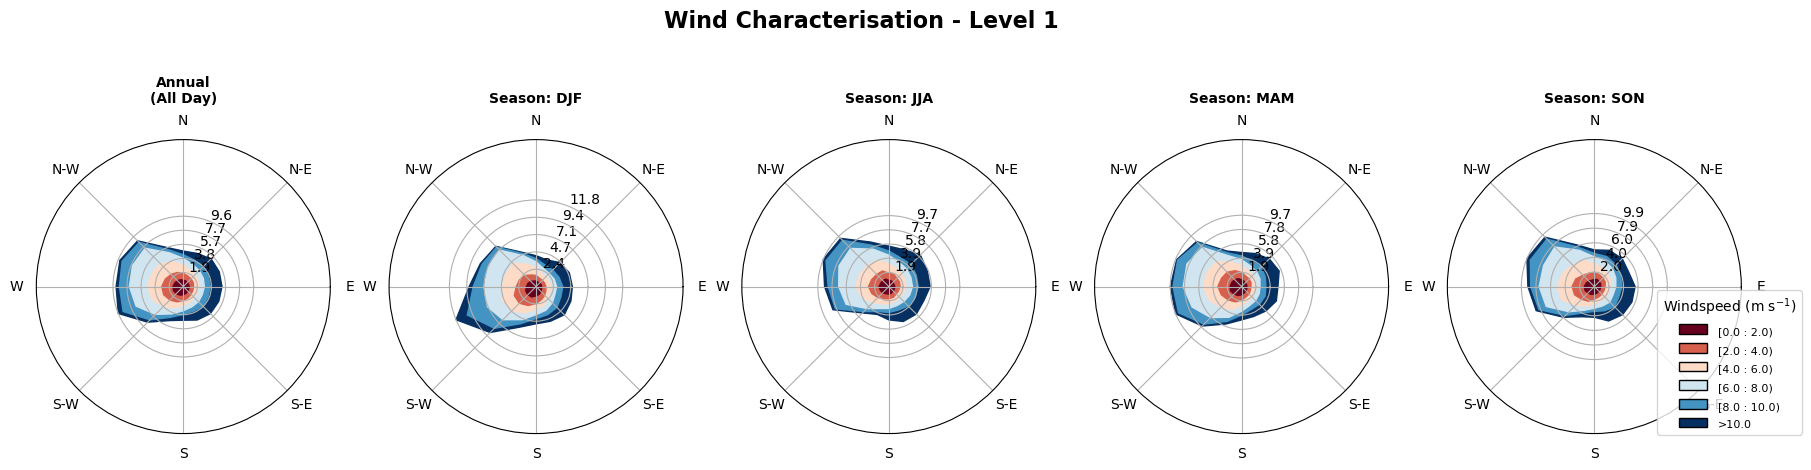

In [12]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

def plot_single_windrose(met_data, bins=[0, 2, 4, 6, 8, 10], limit=20, ax=None, legend=True, title=None):
    """
    Plot a single windrose from x_wind and y_wind features in an xarray Dataset.

    Parameters
    ----------
    data : xarray.Dataset
        Dataset containing 'x_wind' and 'y_wind'. Must be pre-filtered to 
        a single atmospheric level.
    bins : list of float, optional
        Wind speed bin edges. Default [0, 2, 4, 6, 8, 10].
    limit : float, optional
        Maximum radial limit (percentage frequency). Default 20.
    ax : matplotlib.axes.Axes, optional
        Existing axis to plot on. If None, a new figure is created.
    legend : bool, optional
        Whether to display the windspeed legend. Default True.
    title : str, optional
        Title for the individual windrose.

    Returns
    -------
    wax : WindroseAxes
        The generated windrose axis object.
    """
    # 1. Validation: Ensure only one level exists
    if 'levels' in met_data.dims and met_data.levels.size > 1:
        raise ValueError(f"Data contains {data.levels.size} levels. Please select a single level before plotting.")

    # 2. Setup the Windrose Axes
    if ax is None:
        fig = plt.figure(figsize=(6, 6))
        wax = WindroseAxes.from_ax(fig=fig)
    else:
        # Get the position of the provided axis to overlay the WindroseAxes
        fig = ax.get_figure()
        rect = ax.get_position()
        wax = WindroseAxes(fig, rect)
        fig.add_axes(wax)
        ax.set_visible(False) # Hide the original placeholder axis

    # 3. Flatten and Calculate
    u = met_data['x_wind'].values.ravel()
    v = met_data['y_wind'].values.ravel()
    
    mask = ~np.isnan(u) & ~np.isnan(v)
    speed = np.sqrt(u[mask]**2 + v[mask]**2)
    direction = np.rad2deg(np.arctan2(u[mask], v[mask])) % 360

    # 4. Plotting
    wax.contourf(direction, speed, normed=True, bins=bins, cmap=plt.cm.RdBu, nsector=16)
    wax.set_rmax(limit)

    if legend:
        wax.set_legend(title="Windspeed (m s$^{-1}$)", loc='lower right', bbox_to_anchor=(1.2, 0))
    
    if title:
        wax.set_title(title, fontweight='bold', fontsize=10, y=1.1)

    return wax

def plot_wind_characterisation(ds, level_val=1, hour_range=None, bins=[0, 2, 4, 6, 8, 10], limit=20):
    """
    Generate a summary figure with annual and seasonal wind roses side-by-side.

    Parameters
    ----------
    ds : xarray.Dataset
        Input dataset with time, levels, lat, lon.
    level_val : int
        Coordinate value of the level to select.
    hour_range : list, optional
        [start_hour, end_hour] filter.
    bins : list, optional
        Wind speed bins.
    limit : int, optional
        Radial percentage limit.
    """
    # 1. Apply Level Selection
    level_ds = ds.sel(levels=level_val)
    
    # 2. Apply Hour Filter
    if hour_range is not None:
        level_ds = level_ds.where(
            (level_ds['time.hour'] >= hour_range[0]) & 
            (level_ds['time.hour'] <= hour_range[1]), 
            drop=True
        )
        time_label = f"Hours {hour_range[0]}-{hour_range[1]}"
    else:
        time_label = "All Day"

    # 3. Create Figure with Subplots (1 row, 5 columns)
    fig, axes = plt.subplots(1, 5, figsize=(22, 5))
    
    # 4. Annual Plot (First Axis)
    plot_single_windrose(level_ds, bins=bins, limit=limit, ax=axes[0], 
                         legend=False, title=f"Annual\n({time_label})")

    # 5. Seasonal Plots (Remaining Axes)
    # Order them logically
    seasonal_data = level_ds.groupby('time.season')
    
    # Note: groupby seasons usually returns alphabetical (DJF, JJA, MAM, SON)
    for i, (season, data) in enumerate(seasonal_data):
        # We start from index 1 because index 0 is Annual
        plot_single_windrose(data, bins=bins, limit=limit, ax=axes[i+1], 
                             legend=(i == 3), # Show legend only on the last plot
                             title=f"Season: {season}")

    plt.suptitle(f"Wind Characterisation - Level {level_val}", fontsize=16, fontweight='bold', y=1.05)
    plt.show()

# --- Run ---
plot_wind_characterisation(subset, level_val=1)

# OLD CODE

## Initial quiver plot

In [ ]:
def quiver_map(u, v):
    # 1. Compute the time mean
    # Since your data is (lat, lon, time), mean("time") 
    # results in a (lat, lon) 2D array.
    # Nawid - get the meaan u and mean v across time
    u_mean = u.mean("time")
    v_mean = v.mean("time")
    
    # Nawid - cacculate the mean speeds
    # 2. Calculate wind speed from the mean components
    wind_speed = np.sqrt(u_mean**2 + v_mean**2)

    # 3. Setup the Map
    fig = plt.figure(figsize=(10, 12))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # 4. Plot the Background Speed
    # We specify x and y coordinates explicitly to avoid dimension confusion
    im = wind_speed.plot(
        ax=ax, 
        x='lon', y='lat',  # Explicitly tell xarray which dim is which
        transform=ccrs.PlateCarree(),
        cmap='turbo',
        add_colorbar=True,
        cbar_kwargs={'label': 'Mean Wind speed (m s$^{-1}$)', 'orientation': 'horizontal', 'pad': 0.05}
    )

    # 5. Plot the Quiver (Arrows)
    # We use every 10th point to avoid a "black blob"
    skip = 10
    
    # Extract coordinate values and data values for the skip
    lons = u_mean.lon[::skip]
    lats = u_mean.lat[::skip]
    u_vals = u_mean.values[::skip, ::skip]
    v_vals = v_mean.values[::skip, ::skip]

    q = ax.quiver(
        lons, lats, u_vals, v_vals,
        transform=ccrs.PlateCarree(),
        color='black',
        scale=150,
        width=0.002 # Makes the arrow stems thinner and cleaner
    )

    # 6. Map Aesthetics
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.7)
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    plt.title('Mean Wind Speed and Direction')
    plt.show()

# Run the function
quiver_map(u, v)

In [14]:
def plot_windspeed_map(dataset, level=1, timestamp_to_plot=None,skip=1):
    """
    Extracts data and plots a single wind map for a specific level. 
    Can plot either a long-term mean or a specific point in time.

    Parameters
    ----------
    dataset : xarray.Dataset
        The input dataset containing 'x_wind', 'y_wind', and 'levels'.
    level : int, default 1
        The vertical level to extract from the dataset.
    timestamp_to_plot : str, optional
        A specific date string (e.g., '2016-01-01'). If None, the function 
        calculates the mean across all available time steps.

    Returns
    -------
    None
        Displays the resulting matplotlib plot.
    """
    # 1. Select the specific level
    ds_subset = dataset.sel(levels=level)
    
    # 2. Handle Time: Specific vs Mean
    if timestamp_to_plot:
        # Use method='nearest' in case the exact string doesn't match the index
        data = ds_subset.sel(time=timestamp_to_plot, method='nearest')
        u_plot, v_plot = data.x_wind, data.y_wind
        title = f"Wind Speed at Level {level}\nTimestamp: {timestamp_to_plot}"
    else:
        # Calculate the mean over time for the whole year (or subset)
        u_plot = ds_subset.x_wind.mean("time")
        v_plot = ds_subset.y_wind.mean("time")
        title = f"Mean Wind Speed at Level {level}"

    # Use ccrs.PlateCarree() here (fixed the medical_ccrs error)
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    
    # Call the helper function we defined earlier
    quiver_map(u_plot, v_plot, ax,skip=skip)
    
    ax.set_title(title)
    plt.show()

def plot_seasonal_windspeed_map(dataset, level=1,skip=1):
    """
    Creates a 4-panel figure comparing the average wind speed and 
    direction across meteorological seasons (DJF, MAM, JJA, SON).

    Parameters
    ----------
    dataset : xarray.Dataset
        The input dataset. Must have a datetime-indexed 'time' dimension.
    level : int, default 1
        The vertical level to analyze.

    Notes
    -----
    The colorbar is shared across all four subplots to ensure that 
    the color intensities are directly comparable between seasons.
    
    Returns
    -------
    None
        Displays the resulting 4-panel matplotlib figure.
    """
    ds_lev = dataset.sel(levels=level)
    
    # Calculate global max for shared colorbar scaling
    full_mean = np.sqrt(ds_lev.x_wind.mean('time')**2 + ds_lev.y_wind.mean('time')**2)
    max_speed = float(full_mean.max()) * 1.2 # Buffer for visual clarity

    fig, axes = plt.subplots(1, 4, figsize=(24, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    seasons = [('DJF', 'Winter'), ('MAM', 'Spring'), ('JJA', 'Summer'), ('SON', 'Autumn')]

    for i, (season_code, season_name) in enumerate(seasons):
        # Subset by season
        seasonal_data = ds_lev.sel(time=ds_lev.time.dt.season == season_code)
        u_s = seasonal_data.x_wind.mean("time")
        v_s = seasonal_data.y_wind.mean("time")
        
        # Plot on specific subplot axis
        # Only add colorbar to the last plot or handle separately
        im = quiver_map(u_s, v_s, axes[i], max_speed=max_speed, add_colorbar=False,skip=skip)
        axes[i].set_title(season_name)

    # Add one shared colorbar at the bottom
    fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1, label='Wind Speed (m/s)')
    plt.suptitle(f'Seasonal Wind Comparison - Level {level}', fontsize=16)
    plt.show()

## Initial wind rose plot

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

def plot_wind_characterisation(ds, level_val=1, bins=[0, 2, 4, 6, 8, 10], limit=20, hour_range=None):
    """
    Generate annual and seasonal wind roses using cumulative spatial and temporal data.

    This function aggregates all grid points (lat, lon) and time steps for a specific 
    atmospheric level to create a statistical 'wind climate' representation. It 
    produces one annual plot and four seasonal plots (DJF, MAM, JJA, SON).

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset containing 'x_wind' and 'y_wind' variables with dimensions 
        (levels, lat, lon, time).
    level_val : int, optional
        The coordinate value of the atmospheric level to plot (e.g., 1, 3, 6). 
        Default is 1.
    bins : list of float, optional
        Wind speed bin edges for the rose categories. 
        Default is [0, 2, 4, 6, 8, 10].
    limit : float, optional
        The maximum radial limit (percentage frequency) for the rose axes. 
        Ensures consistent scaling across plots. Default 20.
    hour_range : list or tuple of int, optional
        Range of hours [start, end] to include (inclusive). If None, all hours 
        are used. Default is None.

    Returns
    -------
    None
        Displays a series of matplotlib figures.
    """
    # 1. Select the specific level by coordinate value
    level_ds = ds.sel(levels=level_val)
    
    # 2. Apply Hour Range Filter
    if hour_range is not None:
        # Filter for hours inclusive of the range [start, end]
        level_ds = level_ds.where(
            (level_ds['time.hour'] >= hour_range[0]) & 
            (level_ds['time.hour'] <= hour_range[1]), 
            drop=True
        )
        time_label = f"Hours {hour_range[0]}-{hour_range[1]}"
    else:
        time_label = "All Day"

    # 3. Define the groupings: "Annual" + Seasons
    plots_to_make = [("Annual", level_ds)]
    
    # Add seasonal groups
    seasonal_groups = level_ds.groupby('time.season')
    for season, data in seasonal_groups:
        plots_to_make.append((f"Season: {season}", data))

    # 4. Iterate and Plot
    for label, data in plots_to_make:
        # Flatten all dimensions (time, lat, lon) into 1D arrays
        u_flat = data['x_wind'].values.ravel()
        v_flat = data['y_wind'].values.ravel()
        
        # Remove NaNs
        mask = ~np.isnan(u_flat) & ~np.isnan(v_flat)
        u, v = u_flat[mask], v_flat[mask]

        if len(u) == 0:
            print(f"No data found for {label} in specified hour range.")
            continue

        # Calculate Speed and Direction
        speed = np.sqrt(u**2 + v**2)
        direction = np.rad2deg(np.arctan2(u, v)) % 360

        # 5. Setup the Plot
        fig = plt.figure(figsize=(7, 7))
        ax = WindroseAxes.from_ax(fig=fig)
        
        # Use filled contours as requested
        ax.contourf(direction, speed, 
                    normed=True, 
                    bins=bins, 
                    cmap=plt.cm.RdBu,
                    nsector=16) 
        
        # 6. Formatting
        ax.set_rmax(limit) 
        
        plt.title(f"{label}\nLevel: {level_val} | {time_label}\nAll Points & Times", 
                  y=1.1, fontweight='bold')
        
        ax.set_legend(title="Windspeed (m s$^{-1}$)", loc='lower right', 
                      bbox_to_anchor=(1.25, 0))
        
        plt.show()

# --- Run the characterisation ---
# Example: Only plotting for daytime hours (8 AM to 6 PM)
plot_wind_characterisation(subset, level_val=1, limit=20)

### 